# Reconstructing the past: estimating solar radio flux F10.7 from sunspot records
# Ilya Niafiodau, Vlad Zagorodnyuk, Zhanar Sirgebayeva, Skoltech, 2026

In [4]:
import numpy as np
from matplotlib import pyplot as plt

In [51]:
# read data from the .txt files
flux_year, flux_month, flux = np.loadtxt("Radio_flux_monthly_mean.txt", unpack=True)
sunspot_year, sunspot_month, sunspot = np.loadtxt("Sunspot_number_monthly_mean.txt", unpack=True)

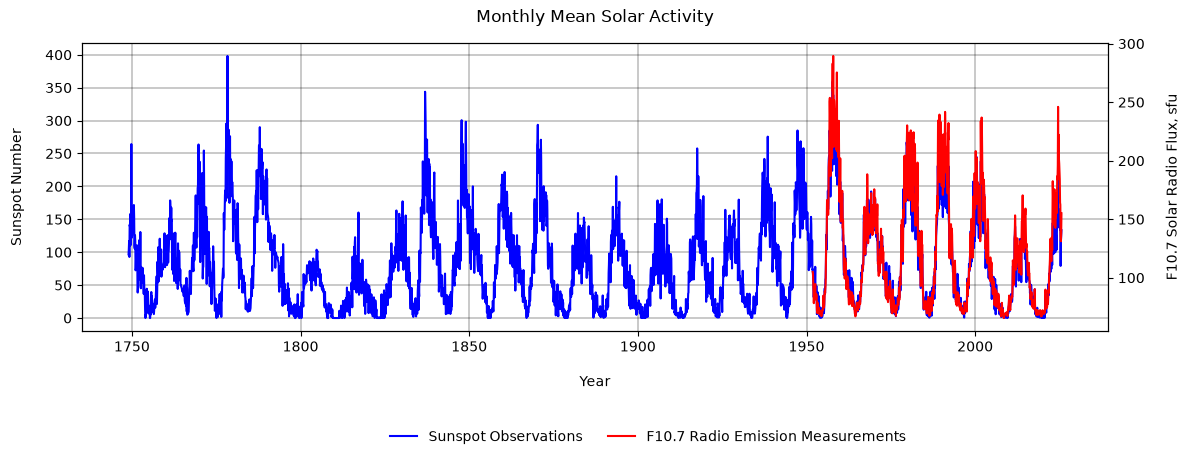

In [52]:
# establish a decimal year time axis
flux_time    = flux_year    + (flux_month    - 1) / 12
sunspot_time = sunspot_year + (sunspot_month - 1) / 12

# plot the monthly mean sunspot number 
# and solar radio flux at 10.7 cm in one chart
def plot_solar_activity_over_time(
    title, x1_data, y1_data, y1_ax_name, x2_data, y2_data, y2_ax_name, is_scatter_plot
):
    fig, ax1 = plt.subplots(figsize=(12, 5))

    # left y-axis: sunspot number
    if is_scatter_plot:
        ax1.scatter(
            x1_data, 
            y1_data, 
            s=2,
            color="blue", 
            label="Sunspot Observations"
        )
    else:
        ax1.plot(
            x1_data, 
            y1_data, 
            color="blue", 
            label="Sunspot Observations"
        )
    ax1.set_title(title, pad=15) 
    ax1.set_xlabel("Year", labelpad=15)
    ax1.set_ylabel(y1_ax_name, labelpad=15) 
    ax1.grid(True, color="black", linewidth=0.3)
    ax1.tick_params(axis="y")
    ax1.legend(
        frameon=False, 
        markerscale=4, 
        ncol=2, 
        loc="upper right", 
        bbox_to_anchor=(0.5, -0.3)
    )

    # right y-axis: F10.7 solar radio flux
    ax2 = ax1.twinx()
    if is_scatter_plot:
        ax2.scatter(
            x2_data, 
            y2_data, 
            s=2,
            color="red", 
            label="F10.7 Radio Emission Measurements"
        )
    else:
        ax2.plot(
            x2_data, 
            y2_data, 
            color="red", 
            label="F10.7 Radio Emission Measurements"
        )
    ax2.set_ylabel(y2_ax_name, labelpad=15) 
    ax2.legend(
        frameon=False, 
        markerscale=4, 
        ncol=2, 
        loc="upper left", 
        bbox_to_anchor=(0.5, -0.3)
    )

    fig.tight_layout()
    plt.show()

# call the self-written function above to plot the datasets from the files
plot_solar_activity_over_time(
    title="Monthly Mean Solar Activity",
    x1_data=sunspot_time,
    y1_data=sunspot,
    y1_ax_name="Sunspot Number",
    x2_data=flux_time,
    y2_data=flux,
    y2_ax_name="F10.7 Solar Radio Flux, sfu",
    is_scatter_plot=False
)

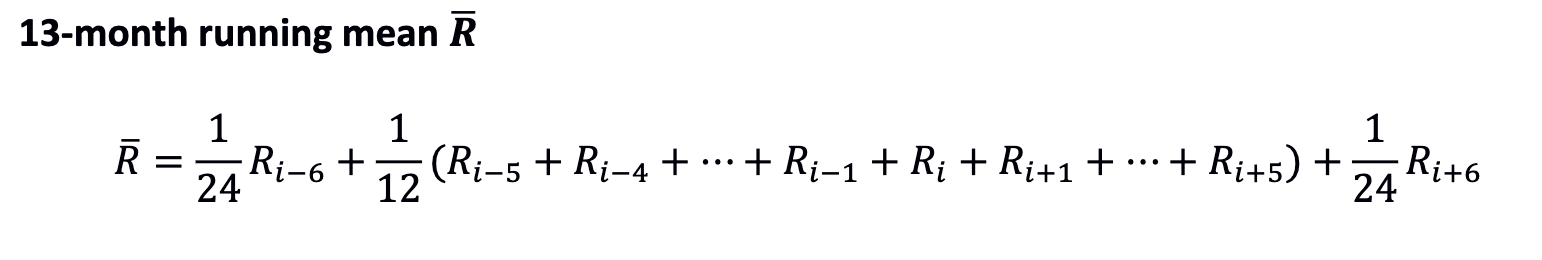

In [7]:
# apply a 13-month running mean 

def smooth(data, time):
    n = len(time)
    running_mean_13 = data.copy()

    for i in range(6, n - 6):
        mean = (data[i-6] + data[i+6]) / 24

        for j in range(i-5, i+6):
            mean += data[j] / 12

        running_mean_13[i] = mean

    return running_mean_13

sunspot_smoothed = smooth(sunspot, sunspot_time)
flux_smoothed = smooth(flux, flux_time)
   

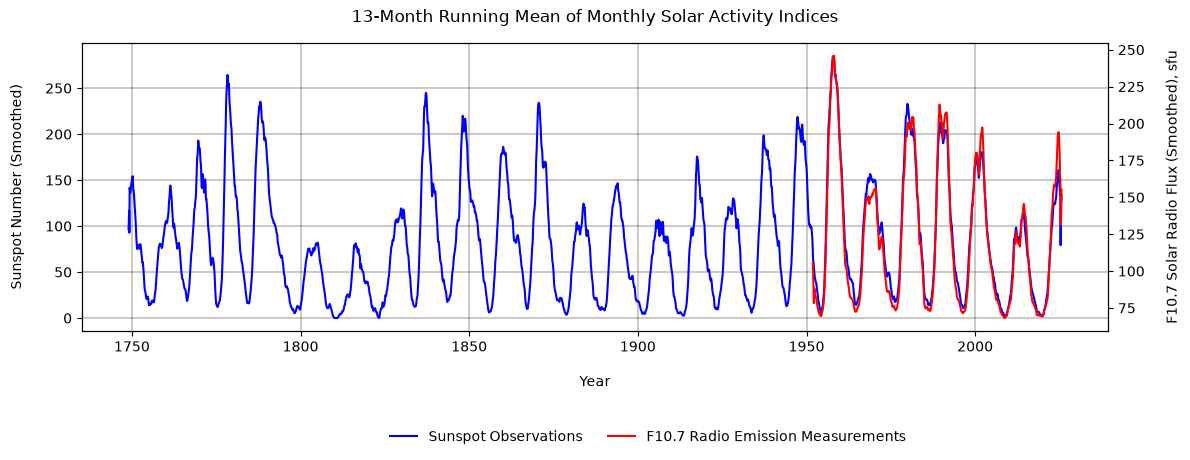

In [8]:
# call the self-written function above to plot the smoothed datasets
plot_solar_activity_over_time(
    title="13-Month Running Mean of Monthly Solar Activity Indices",
    x1_data=sunspot_time,
    y1_data=sunspot_smoothed,
    y1_ax_name="Sunspot Number (Smoothed)",
    x2_data=flux_time,
    y2_data=flux_smoothed,
    y2_ax_name="F10.7 Solar Radio Flux (Smoothed), sfu",
    is_scatter_plot=False
)

Start of the overlap is 1951.833.
End of the overlap is 2025.583.


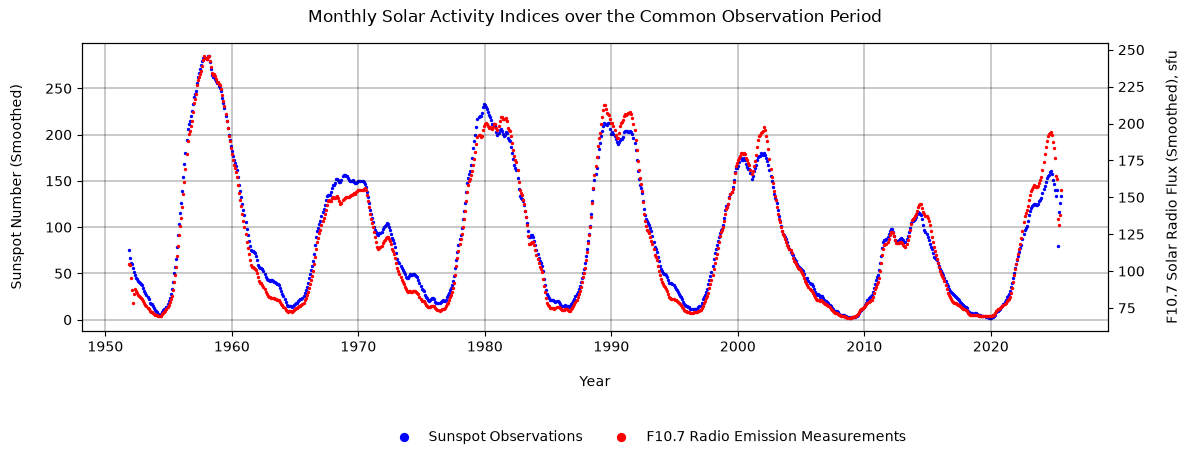

In [9]:
# find an overlapping time frame
common_start = max(sunspot_time[0], flux_time[0])
common_end = min(sunspot_time[-1], flux_time[-1])
print("Start of the overlap is %.3f.\nEnd of the overlap is %.3f." % (common_start, common_end))
sunspot_mask = (sunspot_time >= common_start) & (sunspot_time <= common_end)
flux_mask = (flux_time >= common_start) & (flux_time <= common_end)

# extract data from the common timeline
common_time = sunspot_time[sunspot_mask]
sunspot_smoothed_common = sunspot_smoothed[sunspot_mask]
flux_smoothed_common = flux_smoothed[flux_mask]

# call the self-written function above to make a scatter plot over the found overlapping period
plot_solar_activity_over_time(
    title="Monthly Solar Activity Indices over the Common Observation Period",
    x1_data=common_time,
    y1_data=sunspot_smoothed_common,
    y1_ax_name="Sunspot Number (Smoothed)",
    x2_data=common_time,
    y2_data=flux_smoothed_common,
    y2_ax_name="F10.7 Solar Radio Flux (Smoothed), sfu",
    is_scatter_plot=True
)

# Conclusions:
both dependencies have:
- same periods
- same max and mins points (extremums)

looks like they have a linear dependency

# Multi-dimensional linear regression model:
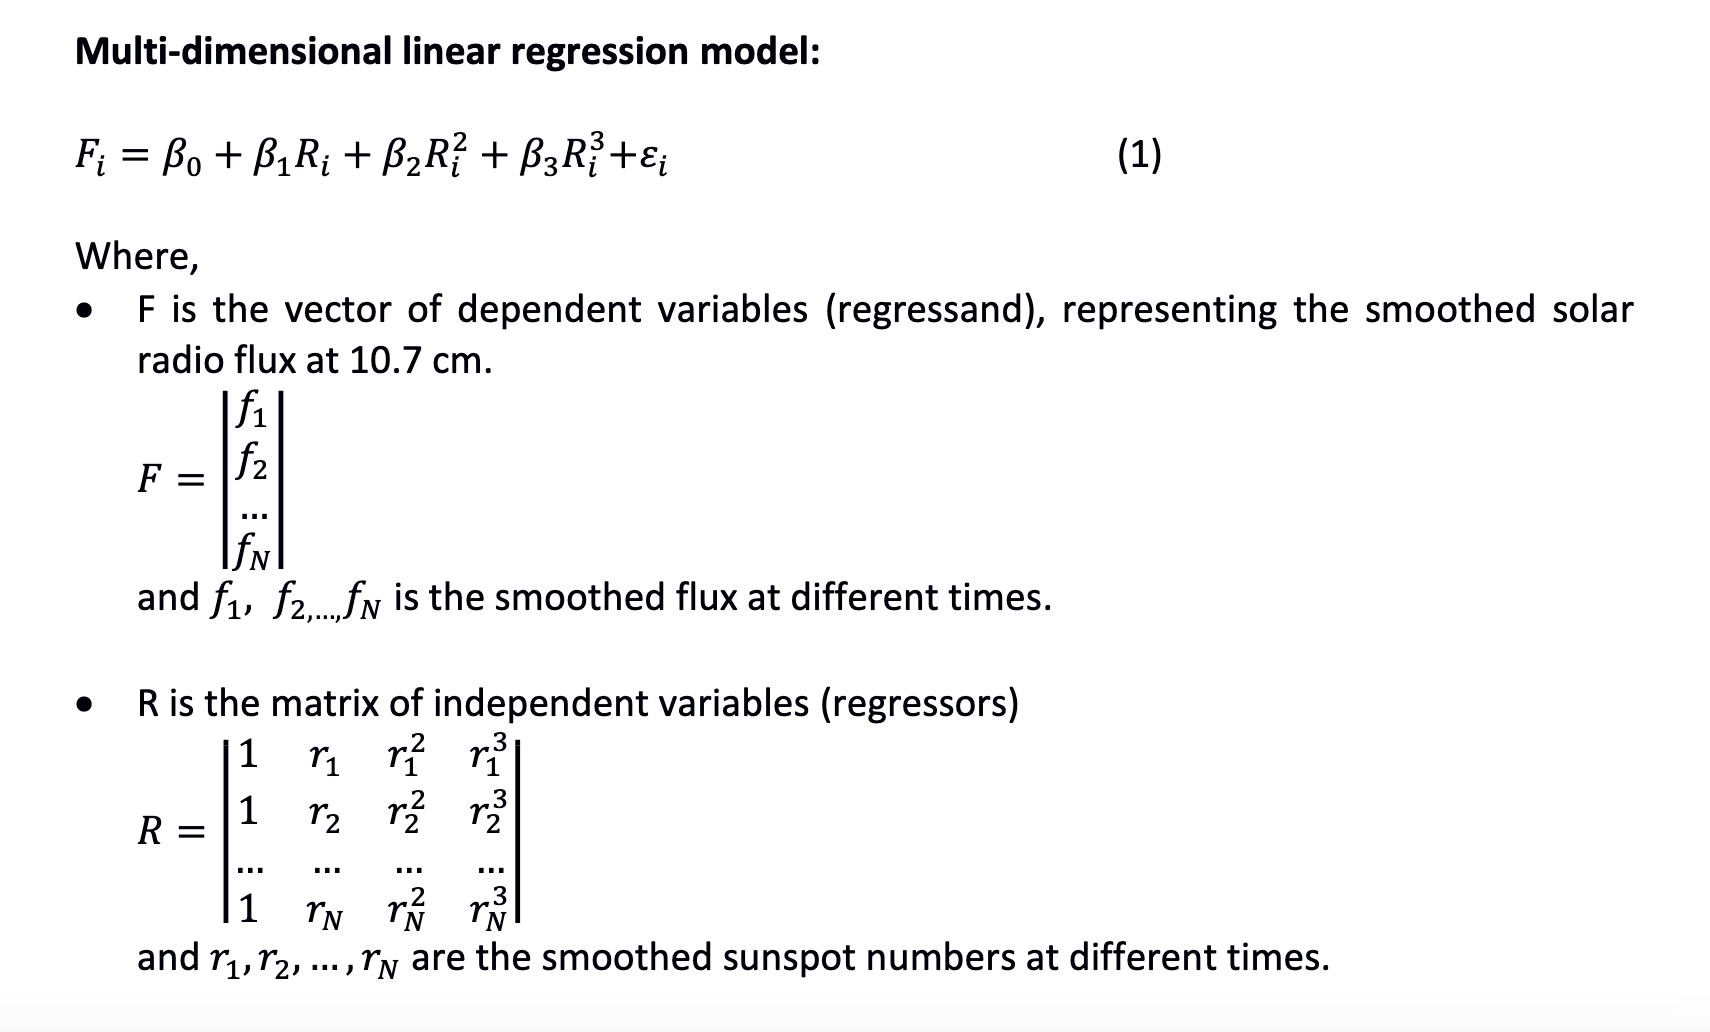
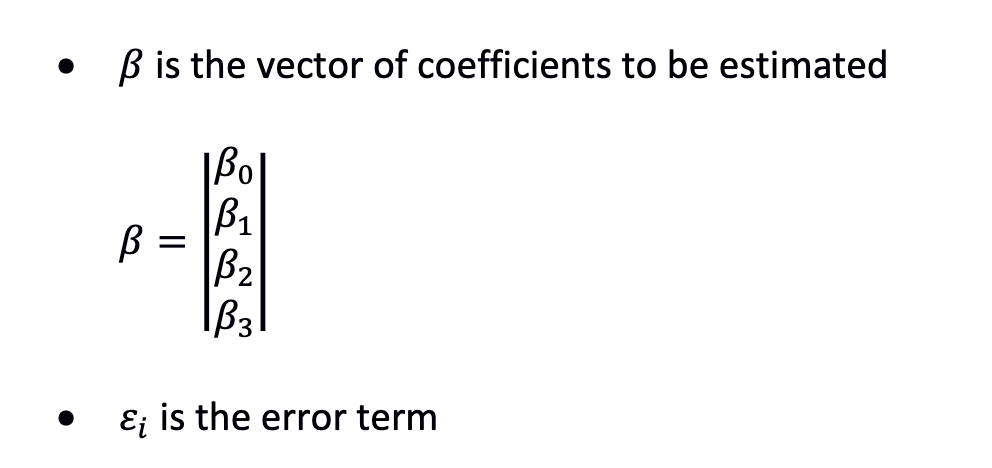

In [10]:
r = sunspot_smoothed_common
f = flux_smoothed_common

# create a matrix of regressors with rows following the pattern: 1, r_i, r_i^2, r_i^3
R = np.column_stack((np.ones(r.size), r, r**2, r**3))

# create a vector of regressands by reshaping the array f
F = f.reshape(-1, 1)

# define a vector of regression coefficients using the LSM
beta = np.linalg.inv(R.T @ R) @ R.T @ F

print("R:", R.shape, " F:", F.shape, " beta:", beta.shape, "\n")
print("beta = %s" % beta)

R: (886, 4)  F: (886, 1)  beta: (4, 1) 

beta = [[ 6.57530080e+01]
 [ 4.70189358e-01]
 [ 1.92170969e-03]
 [-5.07032158e-06]]


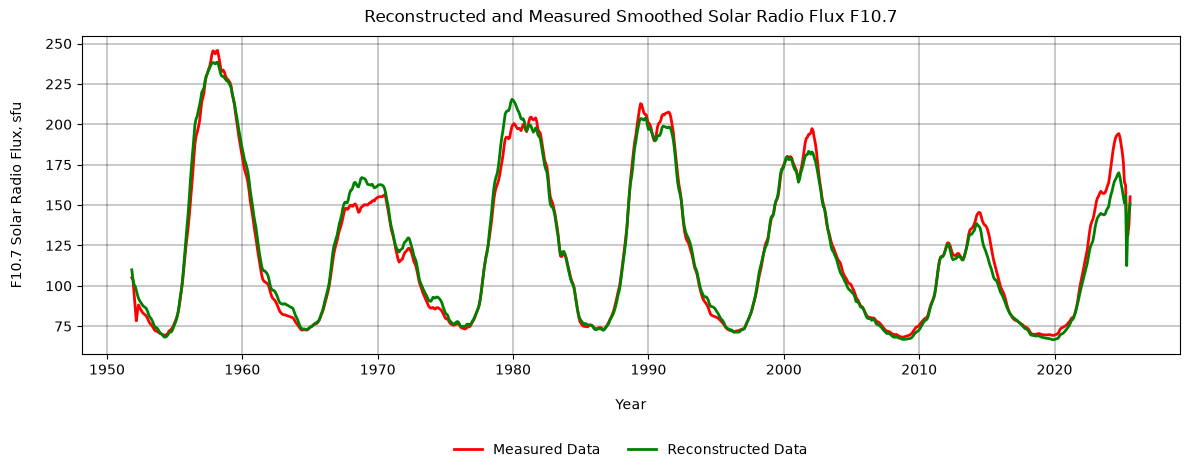

In [35]:
# reconstruct the smoothed F10.7 flux:
# F = beta0 + beta1*r + beta2*r^2 + beta3*r^3
F_reconstructed = R @ beta
flux_array_reconstructed = F_reconstructed.ravel()

# plot the reconstructed F10.7 flux and the initial smoothed F10.7 flux in a single chart
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(common_time, flux_smoothed_common, linewidth=2, color="red", label="Measured Data")
ax.plot(common_time, flux_array_reconstructed, linewidth=2, color="green", label="Reconstructed Data")
ax.set_title("Reconstructed and Measured Smoothed Solar Radio Flux F10.7", pad=10)
ax.set_xlabel("Year", labelpad=15)
ax.set_ylabel("F10.7 Solar Radio Flux, sfu", labelpad=15)
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.24))
fig.tight_layout()
plt.show()

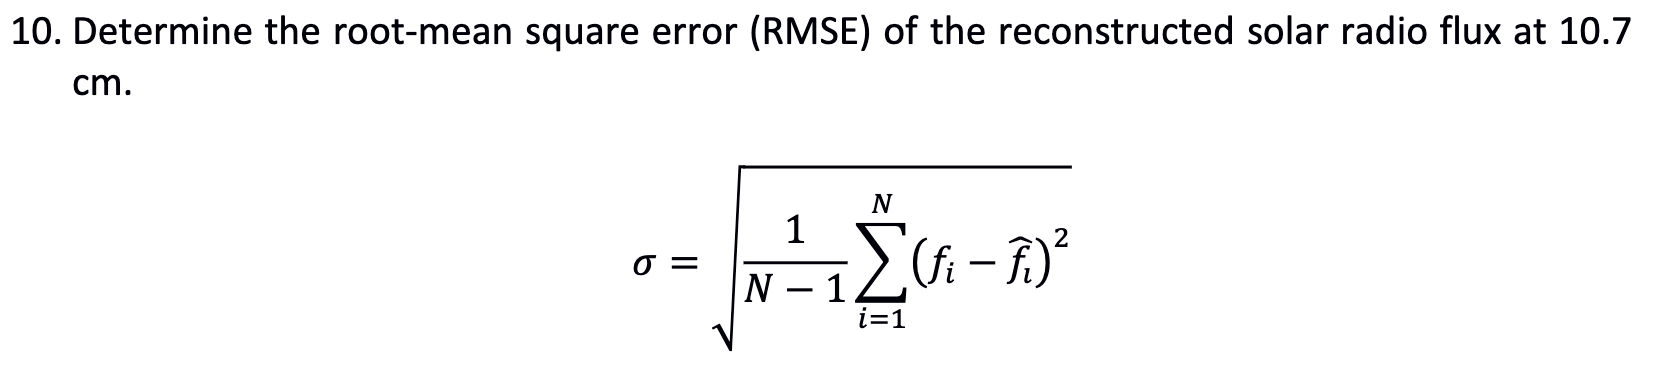

In [12]:
N = flux_array_reconstructed.size
squared_error = 0

for i in range(N):
    error = flux_array_reconstructed[i] - flux_smoothed_common[i]
    squared_error += error**2

rmse = (squared_error / (N - 1))**0.5

print("RMSE: ", rmse)

RMSE:  6.2253299836630545


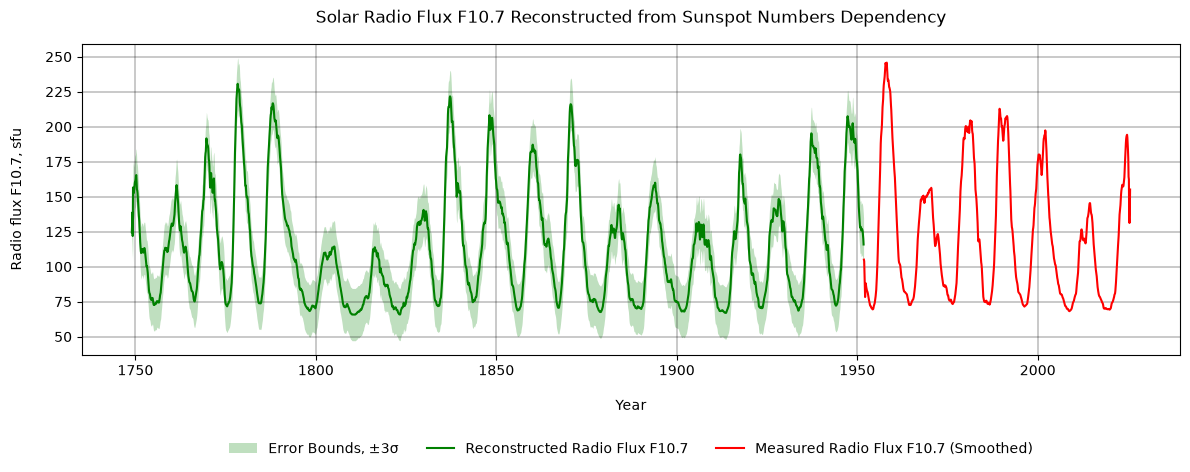

In [36]:
# determine the time frame and sunspot data chunk for the reconstruction of the F10.7 flux
past_mask = sunspot_time < flux_time[0]
past_time = sunspot_time[past_mask]
sunspot_smoothed_past = sunspot_smoothed[past_mask]

# reconstruct the F10.7 flux using linear regression coefficients obtained from the overlapping period
r_past = sunspot_smoothed_past
R_past = np.column_stack((np.ones(r_past.size), r_past, r_past**2, r_past**3))
flux_array_reconstructed_past = (R_past @ beta).ravel()

# error bounds for the chunk: +-3 sigma
flux_lower_bound = flux_array_reconstructed_past - 3 * rmse
flux_upper_bound = flux_array_reconstructed_past + 3 * rmse

# plotting the reconstructed F10.7 flux and the measured smoothed F10.7 flux in a single chart
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(past_time, flux_lower_bound, flux_upper_bound, color="green", alpha=0.25, linewidth=0, label="Error Bounds, ±3σ")
ax.plot(past_time, flux_array_reconstructed_past, linewidth=1.5, color="green", label="Reconstructed Radio Flux F10.7")
ax.plot(flux_time, flux_smoothed, linewidth=1.5, color="red", label="Measured Radio Flux F10.7 (Smoothed)")
ax.set_title("Solar Radio Flux F10.7 Reconstructed from Sunspot Numbers Dependency", pad=15)
ax.set_xlabel("Year", labelpad=15)
ax.set_ylabel("Radio flux F10.7, sfu", labelpad=15)
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.24))
fig.tight_layout()
plt.show()

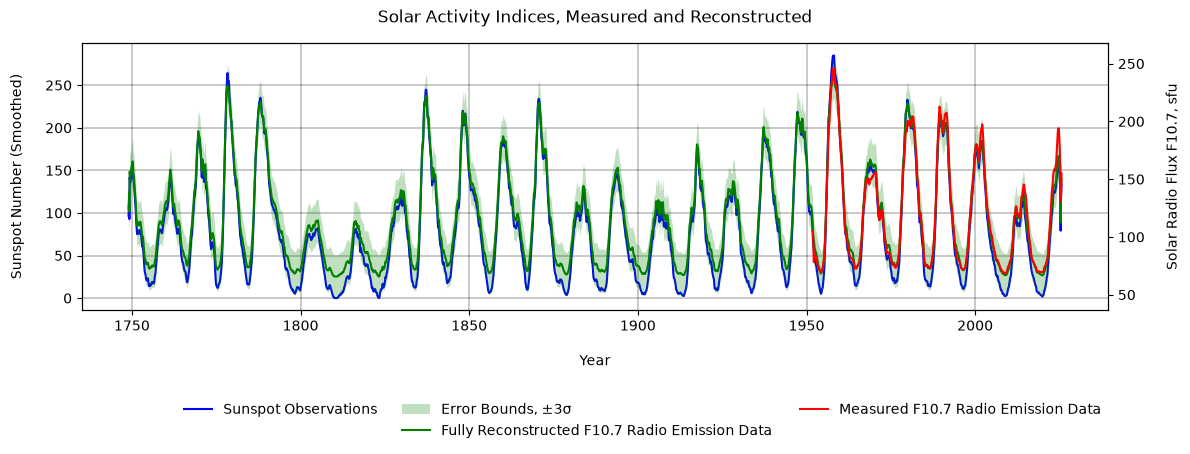

In [53]:
# apply the model to the whole period where sunspot numbers are available
r_full = sunspot_smoothed
R_full = np.column_stack((np.ones(r_full.size), r_full, r_full**2, r_full**3))
flux_array_reconstructed_full = (R_full @ beta).ravel()

# error bounds: +-3 sigma
flux_lower_bound_full = flux_array_reconstructed_full - 3 * rmse
flux_upper_bound_full = flux_array_reconstructed_full + 3 * rmse

# plot the reconstructed F10.7 flux for the past years, 
# the measured F10.7 flux for the recent years,
# and the smoothed sunspot number in a single chart
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(sunspot_time, sunspot_smoothed, linewidth=1.5, color="blue", label="Sunspot Observations")
ax1.set_title("Solar Activity Indices, Measured and Reconstructed", pad=15)
ax1.set_xlabel("Year", labelpad=15)
ax1.set_ylabel("Sunspot Number (Smoothed)", labelpad=15)
ax1.grid(True, color="black", linewidth=0.3)
ax1.tick_params(axis="y")
ax1.legend(
    frameon=False, 
    markerscale=4, 
    ncol=2, 
    loc="upper right", 
    bbox_to_anchor=(0.3, -0.3)
)


ax2 = ax1.twinx()
ax2.fill_between(sunspot_time, flux_lower_bound_full, flux_upper_bound_full, color="green", alpha=0.25, linewidth=0, label="Error Bounds, ±3σ")
ax2.plot(sunspot_time, flux_array_reconstructed_full, linewidth=1.5, color="green", label="Fully Reconstructed F10.7 Radio Emission Data")
ax2.plot(flux_time, flux_smoothed, linewidth=1.5, color="red", label="Measured F10.7 Radio Emission Data")
ax2.set_ylabel("Solar Radio Flux F10.7, sfu", labelpad=15)

ax2.legend(
    frameon=False, 
    markerscale=4, 
    ncol=2, 
    loc="upper left", 
    bbox_to_anchor=(0.3, -0.3)
)

fig.tight_layout()
plt.show()

Measured points inside ±3σ: 873 of 886 (98.5%)


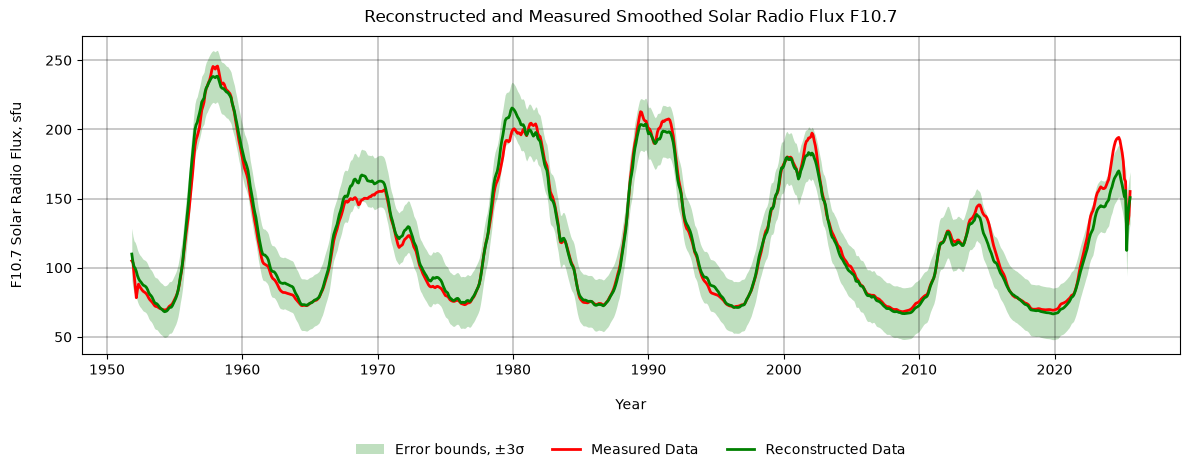

In [62]:
# reconstructed model with +-3 sigma band and measured points on the common period
inside = (flux_smoothed >= flux_lower_bound) & (flux_smoothed <= flux_upper_bound)
print(f"Measured points inside ±3σ: {inside.sum()} of {inside.size} ({100 * inside.mean():.1f}%)")

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(flux_time, flux_lower_bound, flux_upper_bound, color="green", alpha=0.25, linewidth=0, label="Error bounds, ±3σ")
ax.plot(common_time, flux_smoothed_common, linewidth=2, color="red", label="Measured Data")
ax.plot(common_time, flux_array_reconstructed, linewidth=2, color="green", label="Reconstructed Data")
ax.set_title("Reconstructed and Measured Smoothed Solar Radio Flux F10.7", pad=10)
ax.set_xlabel("Year", labelpad=15)
ax.set_ylabel("F10.7 Solar Radio Flux, sfu", labelpad=15)
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.24))
fig.tight_layout()
plt.show()